In [22]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "character_popularity_analysis.csv"
)

characters = pd.read_csv(DATA_FILE)

print("Rows:", len(characters))
print("Anime:", characters["anime_id"].nunique())
print("Characters:", characters["character_id"].nunique())

characters.head()

Rows: 11269
Anime: 250
Characters: 8904


,anime_id,character_id,character_name,character_native_name,character_role,character_gender,character_age,character_favourites,character_image_url,character_url,snapshot_date,title_display,format,release_year,genres,average_score,anime_popularity,anime_favourites
0,16498,40881,Mikasa Ackerman,ミカサ・アッカーマン,MAIN,Female,15-,25583,https://s4.anilist.co/file/anilistcdn/characte...,https://anilist.co/character/40881,2026-09-26,Attack on Titan,TV,2013,Action|Drama|Fantasy|Mystery,85,1058434,78821
1,16498,40882,Eren Yeager,エレン・イェーガー,MAIN,Male,15-,31874,https://s4.anilist.co/file/anilistcdn/characte...,https://anilist.co/character/40882,2026-09-26,Attack on Titan,TV,2013,Action|Drama|Fantasy|Mystery,85,1058434,78821
2,16498,45627,Levi,リヴァイ,SUPPORTING,Male,NaN,38336,https://s4.anilist.co/file/anilistcdn/characte...,https://anilist.co/character/45627,2026-09-26,Attack on Titan,TV,2013,Action|Drama|Fantasy|Mystery,85,1058434,78821
3,16498,45887,Sasha Blouse,サシャ・ブラウス,SUPPORTING,Female,16-,8145,https://s4.anilist.co/file/anilistcdn/characte...,https://anilist.co/character/45887,2026-09-26,Attack on Titan,TV,2013,Action|Drama|Fantasy|Mystery,85,1058434,78821
4,16498,46484,Reiner Braun,ライナー・ブラウン,SUPPORTING,Male,17-,7702,https://s4.anilist.co/file/anilistcdn/characte...,https://anilist.co/character/46484,2026-09-26,Attack on Titan,TV,2013,Action|Drama|Fantasy|Mystery,85,1058434,78821


In [24]:
roles_per_anime = (
    characters
    .groupby("anime_id")["character_role"]
    .agg(set)
)

eligible_anime_ids = roles_per_anime[
    roles_per_anime.apply(
        lambda roles: {
            "MAIN",
            "SUPPORTING",
        }.issubset(roles)
    )
].index

eligible = characters[
    characters["anime_id"].isin(
        eligible_anime_ids
    )
].copy()

print(
    "Anime eligible for comparison:",
    eligible["anime_id"].nunique(),
)

print(
    "Anime excluded:",
    characters["anime_id"].nunique()
    - eligible["anime_id"].nunique(),
)

Anime eligible for comparison: 250
Anime excluded: 0


In [25]:
highest_favourites = (
    eligible
    .groupby("anime_id")[
        "character_favourites"
    ]
    .transform("max")
)

winner_candidates = eligible[
    eligible["character_favourites"]
    == highest_favourites
].copy()

winner_summary = (
    winner_candidates
    .groupby("anime_id")
    .agg(
        anime_title=(
            "title_display",
            "first",
        ),
        winner_names=(
            "character_name",
            lambda names: " | ".join(names),
        ),
        winning_roles=(
            "character_role",
            lambda roles: "|".join(
                sorted(set(roles))
            ),
        ),
        winning_favourites=(
            "character_favourites",
            "max",
        ),
        number_of_winners=(
            "character_id",
            "nunique",
        ),
    )
    .reset_index()
)

winner_summary.head(10)

,anime_id,anime_title,winner_names,winning_roles,winning_favourites,number_of_winners
0,1,Cowboy Bebop,Spike Spiegel,MAIN,14331,1
1,19,Monster,Johan Liebert,MAIN,11347,1
2,20,Naruto,Itachi Uchiha,SUPPORTING,21467,1
3,21,ONE PIECE,Luffy Monkey,MAIN,36030,1
4,30,Neon Genesis Evangelion,Asuka Langley Souryuu,MAIN,14675,1
5,32,Neon Genesis Evangelion: The End of Evangelion,Asuka Langley Souryuu,MAIN,14675,1
6,47,Akira,Shoutarou Kaneda,MAIN,1136,1
7,121,Fullmetal Alchemist,Edward Elric,MAIN,19260,1
8,164,Princess Mononoke,San,MAIN,2471,1
9,199,Spirited Away,Haku,MAIN,2874,1


In [26]:
def classify_winner(winning_roles):
    if winning_roles == "MAIN":
        return "Main character"

    if winning_roles == "SUPPORTING":
        return "Supporting character"

    return "Mixed-role tie"


winner_summary["winner_type"] = (
    winner_summary["winning_roles"]
    .apply(classify_winner)
)

winner_counts = (
    winner_summary["winner_type"]
    .value_counts()
)

winner_percentages = (
    winner_summary["winner_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

winner_results = pd.DataFrame(
    {
        "anime_count": winner_counts,
        "percentage": winner_percentages,
    }
)

winner_results

,anime_count,percentage
winner_type,,
Main character,211,84.4
Supporting character,39,15.6


Among the 250 most-popular non-adult anime entries on AniList, the character with the highest global AniList favourite count was a main character in 84.4% of entries and a supporting character in 15.6%.

In [27]:
supporting_winners = (
    winner_summary[
        winner_summary["winner_type"]
        == "Supporting character"
    ]
    .sort_values(
        "winning_favourites",
        ascending=False,
    )
)

supporting_winners[
    [
        "anime_title",
        "winner_names",
        "winning_favourites",
    ]
].head(20)

,anime_title,winner_names,winning_favourites
215,JUJUTSU KAISEN 0,Satoru Gojou,39436
245,JUJUTSU KAISEN Season 3: The Culling Game Part 1,Satoru Gojou,39436
216,Attack on Titan Final Season Part 2,Levi,38336
101,Attack on Titan Season 2,Levi,38336
66,Attack on Titan,Levi,38336
182,Attack on Titan Final Season,Levi,38336
231,Attack on Titan Final Season THE FINAL CHAPTER...,Levi,38336
244,Chainsaw Man – The Movie: Reze Arc,Makima,22269
2,Naruto,Itachi Uchiha,21467
25,Naruto: Shippuden,Itachi Uchiha,21467


In [28]:
supporting_winner_rows = winner_candidates[
    winner_candidates["character_role"]
    == "SUPPORTING"
].copy()

unique_supporting_winners = (
    supporting_winner_rows
    .groupby(
        [
            "character_id",
            "character_name",
        ]
    )
    .agg(
        anime_entries_won=(
            "anime_id",
            "nunique",
        ),
        favourites=(
            "character_favourites",
            "max",
        ),
        anime_titles=(
            "title_display",
            lambda titles: " | ".join(
                sorted(set(titles))
            ),
        ),
    )
    .reset_index()
    .sort_values(
        [
            "anime_entries_won",
            "favourites",
        ],
        ascending=[False, False],
    )
)

print(
    "Supporting-winning anime entries:",
    supporting_winner_rows[
        "anime_id"
    ].nunique()
)

print(
    "Unique supporting winners:",
    unique_supporting_winners[
        "character_id"
    ].nunique()
)

unique_supporting_winners.head(20)

Supporting-winning anime entries: 39
Unique supporting winners: 23


,character_id,character_name,anime_entries_won,favourites,anime_titles
7,45627,Levi,5,38336,Attack on Titan | Attack on Titan Final Season...
14,89220,Shouto Todoroki,4,16814,My Hero Academia | My Hero Academia Season 3 |...
1,500,Sakura Matou,3,17777,Fate/Zero | Fate/Zero Season 2 | Fate/stay nig...
13,89122,Albedo,3,5982,Overlord | Overlord II | Overlord III
17,127691,Satoru Gojou,2,39436,JUJUTSU KAISEN 0 | JUJUTSU KAISEN Season 3: Th...
0,14,Itachi Uchiha,2,21467,Naruto | Naruto: Shippuden
10,71933,Karma Akabane,2,10569,Assassination Classroom | Assassination Classr...
18,130848,Benimaru Shinmon,2,6781,Fire Force | Fire Force Season 2
12,87655,Ais Wallenstein,2,5455,Is It Wrong to Try to Pick Up Girls in a Dunge...
20,137080,Makima,1,22269,Chainsaw Man – The Movie: Reze Arc


In [29]:
role_leaders = (
    eligible
    .groupby(
        [
            "anime_id",
            "title_display",
            "character_role",
        ]
    )["character_favourites"]
    .max()
    .unstack("character_role")
    .reset_index()
)

role_leaders["supporting_advantage"] = (
    role_leaders["SUPPORTING"]
    - role_leaders["MAIN"]
)

role_leaders["supporting_to_main_ratio"] = (
    role_leaders["SUPPORTING"]
    / role_leaders["MAIN"].replace(0, pd.NA)
)

strongest_supporting_upsets = (
    role_leaders[
        role_leaders["supporting_advantage"] > 0
    ]
    .sort_values(
        "supporting_advantage",
        ascending=False,
    )
)

strongest_supporting_upsets.head(20)

character_role,anime_id,title_display,MAIN,SUPPORTING,supporting_advantage,supporting_to_main_ratio
215,131573,JUJUTSU KAISEN 0,11693,39436,27743,3.372616
245,172463,JUJUTSU KAISEN Season 3: The Culling Game Part 1,21298,39436,18138,1.851629
164,102883,JoJo's Bizarre Adventure: Golden Wind,6819,14234,7415,2.087403
66,16498,Attack on Titan,31874,38336,6462,1.202736
231,146984,Attack on Titan Final Season THE FINAL CHAPTER...,31874,38336,6462,1.202736
101,20958,Attack on Titan Season 2,31874,38336,6462,1.202736
182,110277,Attack on Titan Final Season,31874,38336,6462,1.202736
216,131681,Attack on Titan Final Season Part 2,31874,38336,6462,1.202736
46,10087,Fate/Zero,12157,17777,5620,1.462285
53,11741,Fate/Zero Season 2,12157,17777,5620,1.462285


The purpose of cell 7 and 8 is to investigate whether the 39 supporting-character wins represent many different characters or mostly the same icons repeated across sequels. For example, Levi winning several Attack on Titan seasons counts as several times, however with running unique supporting winners code, Levi remains one person.

With 39 supporting characters winning anime entries and there are 23 unique supporting characters, this shows that repeated seasons do matter. However, the result is not being driven by only two or three characters. 

In [30]:
role_leader_characters = (
    eligible
    .sort_values(
        "character_favourites",
        ascending=False,
    )
    .drop_duplicates(
        subset=[
            "anime_id",
            "character_role",
        ]
    )
)

main_leaders = (
    role_leader_characters[
        role_leader_characters[
            "character_role"
        ] == "MAIN"
    ]
    [
        [
            "anime_id",
            "title_display",
            "character_id",
            "character_name",
            "character_favourites",
        ]
    ]
    .rename(
        columns={
            "character_id": "main_character_id",
            "character_name": "top_main_character",
            "character_favourites": "main_favourites",
        }
    )
)

supporting_leaders = (
    role_leader_characters[
        role_leader_characters[
            "character_role"
        ] == "SUPPORTING"
    ]
    [
        [
            "anime_id",
            "character_id",
            "character_name",
            "character_favourites",
        ]
    ]
    .rename(
        columns={
            "character_id": "supporting_character_id",
            "character_name": "top_supporting_character",
            "character_favourites": "supporting_favourites",
        }
    )
)

matchups = main_leaders.merge(
    supporting_leaders,
    on="anime_id",
    how="inner",
)

matchups["supporting_advantage"] = (
    matchups["supporting_favourites"]
    - matchups["main_favourites"]
)

matchups["supporting_to_main_ratio"] = (
    matchups["supporting_favourites"]
    / matchups["main_favourites"].replace(
        0,
        pd.NA,
    )
)

matchups["winner_role"] = matchups[
    "supporting_advantage"
].apply(
    lambda difference: (
        "SUPPORTING"
        if difference > 0
        else "MAIN"
    )
)

strongest_upsets = (
    matchups[
        matchups["winner_role"]
        == "SUPPORTING"
    ]
    .sort_values(
        "supporting_advantage",
        ascending=False,
    )
)

strongest_upsets[
    [
        "title_display",
        "top_main_character",
        "main_favourites",
        "top_supporting_character",
        "supporting_favourites",
        "supporting_advantage",
        "supporting_to_main_ratio",
    ]
].head(15)

,title_display,top_main_character,main_favourites,top_supporting_character,supporting_favourites,supporting_advantage,supporting_to_main_ratio
105,JUJUTSU KAISEN 0,Yuuta Okkotsu,11693,Satoru Gojou,39436,27743,3.372616
31,JUJUTSU KAISEN Season 3: The Culling Game Part 1,Yuuji Itadori,21298,Satoru Gojou,39436,18138,1.851629
152,JoJo's Bizarre Adventure: Golden Wind,Giorno Giovanna,6819,Joutarou Kuujou,14234,7415,2.087403
8,Attack on Titan Final Season Part 2,Eren Yeager,31874,Levi,38336,6462,1.202736
9,Attack on Titan,Eren Yeager,31874,Levi,38336,6462,1.202736
7,Attack on Titan Final Season,Eren Yeager,31874,Levi,38336,6462,1.202736
6,Attack on Titan Final Season THE FINAL CHAPTER...,Eren Yeager,31874,Levi,38336,6462,1.202736
10,Attack on Titan Season 2,Eren Yeager,31874,Levi,38336,6462,1.202736
102,Fate/Zero Season 2,Artoria Pendragon,12157,Sakura Matou,17777,5620,1.462285
103,Fate/Zero,Artoria Pendragon,12157,Sakura Matou,17777,5620,1.462285


In [31]:
unique_matchups = (
    matchups
    .drop_duplicates(
        subset=[
            "main_character_id",
            "supporting_character_id",
        ]
    )
    .copy()
)

unique_matchup_results = (
    unique_matchups["winner_role"]
    .value_counts()
    .rename_axis("winner_role")
    .reset_index(name="matchup_count")
)

unique_matchup_results["percentage"] = (
    unique_matchup_results[
        "matchup_count"
    ]
    / unique_matchup_results[
        "matchup_count"
    ].sum()
    * 100
).round(1)

print(
    "Original anime entries:",
    len(matchups),
)

print(
    "Unique main-supporting matchups:",
    len(unique_matchups),
)

unique_matchup_results

Original anime entries: 250
Unique main-supporting matchups: 203


,winner_role,matchup_count,percentage
0,MAIN,177,87.2
1,SUPPORTING,26,12.8


This code was to prevent any oversights from happening with anime series having multiple seasons, it may affect the scores of the winner roles. 

After collapsing repeated main vs supporting pairs, supporting wins fall from 15.6% to 12.8%. A small difference of 2.8 percentage points with what we initially thought. 

We can conclude for now that main characters usually lead the fandom, but supporting characters still came out on top in approximatelu 13-16% of the comparisons, depending on how repeated seasons were handled. That is roughly one in every 6-8 comparisons. 

In [32]:
#Summarizing the head to head gaps

matchups["main_to_supporting_ratio"] = (
    matchups["main_favourites"]
    / matchups["supporting_favourites"].replace(
        0,
        pd.NA,
    )
)

comparison_summary = pd.DataFrame(
    {
        "metric": [
            "Median top-main favourites",
            "Median top-supporting favourites",
            "Median main/supporting ratio",
            "Mean main/supporting ratio",
            "Supporting wins",
            "Main wins",
        ],
        "value": [
            matchups["main_favourites"].median(),
            matchups["supporting_favourites"].median(),
            matchups[
                "main_to_supporting_ratio"
            ].median(),
            matchups[
                "main_to_supporting_ratio"
            ].mean(),
            (
                matchups["winner_role"]
                == "SUPPORTING"
            ).sum(),
            (
                matchups["winner_role"]
                == "MAIN"
            ).sum(),
        ],
    }
)

comparison_summary

,metric,value
0,Median top-main favourites,9074.000000
1,Median top-supporting favourites,2377.000000
2,Median main/supporting ratio,3.556071
3,Mean main/supporting ratio,9.708410
4,Supporting wins,39.000000
5,Main wins,211.000000


To handle the skewedness of the results as few gigantic characters such as Gojo Satoru can pull the average upward.

9074/2377 = 3.82
Separate median of all entry-level rations are 3.56x
Two overall medians is not necessarily identical to the median of 250 individual ratios

Main characters usually led comforably. Across the sampled entries, the typical top main character had around 2.6 times the favorites of the top supporting character.

In [33]:
#Testing the paired difference, top main chara vs top supporting chara

from scipy.stats import wilcoxon

test_result = wilcoxon(
    matchups["main_favourites"],
    matchups["supporting_favourites"],
    alternative="two-sided",
)

print(
    "Wilcoxon statistic:",
    round(test_result.statistic, 2),
)

print(
    "P-value:",
    test_result.pvalue,
)


Wilcoxon statistic: 2839.0
P-value: 3.031145829149915e-29


The P value being 3.03 x 10^-29 means that it is very small which suggests that there is a very strong evidence that the paired favorite counts for top main and top supporting characters don't typically come from equal distributions. 

In [34]:
#Which genres has the most top supporting charas?

anime_genres = (
    eligible[
        [
            "anime_id",
            "genres",
        ]
    ]
    .drop_duplicates(
        subset=["anime_id"]
    )
)

genre_analysis = matchups.merge(
    anime_genres,
    on="anime_id",
    how="left",
)

genre_analysis["supporting_win"] = (
    genre_analysis["winner_role"]
    == "SUPPORTING"
).astype(int)

genre_analysis["genre"] = (
    genre_analysis["genres"]
    .str.split("|")
)

genre_analysis = genre_analysis.explode(
    "genre"
)

genre_results = (
    genre_analysis
    .groupby("genre")
    .agg(
        anime_entries=(
            "anime_id",
            "nunique",
        ),
        supporting_wins=(
            "supporting_win",
            "sum",
        ),
    )
    .reset_index()
)

genre_results["supporting_win_rate"] = (
    genre_results["supporting_wins"]
    / genre_results["anime_entries"]
    * 100
).round(1)

genre_results = (
    genre_results[
        genre_results["anime_entries"] >= 15
    ]
    .sort_values(
        "supporting_win_rate",
        ascending=False,
    )
)

genre_results

,genre,anime_entries,supporting_wins,supporting_win_rate
5,Fantasy,92,22,23.9
0,Action,153,35,22.9
1,Adventure,87,19,21.8
13,Sci-Fi,38,7,18.4
10,Mystery,46,8,17.4
3,Drama,144,22,15.3
16,Supernatural,93,14,15.1
2,Comedy,106,14,13.2
4,Ecchi,20,2,10.0
6,Horror,21,2,9.5


VISUALIZATION

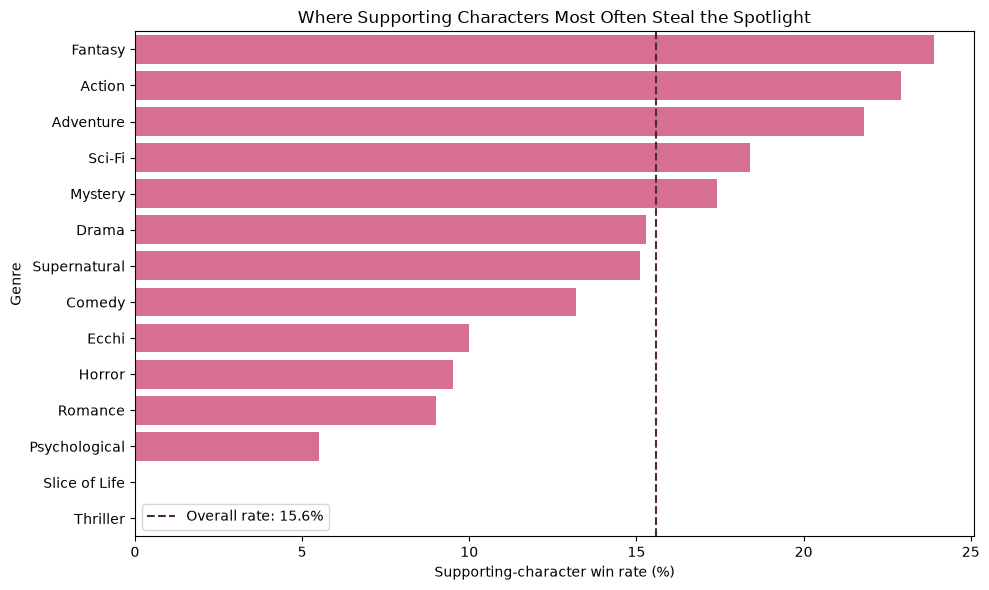

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=genre_results,
    x="supporting_win_rate",
    y="genre",
    color="#E85D8E",
)

plt.axvline(
    15.6,
    color="#4B2E2B",
    linestyle="--",
    label="Overall rate: 15.6%",
)

plt.title(
    "Where Supporting Characters Most Often Steal the Spotlight"
)

plt.xlabel(
    "Supporting-character win rate (%)"
)

plt.ylabel("Genre")

plt.legend()

plt.tight_layout()
plt.show()

This shows that supporting characters most often steals the spotlight in genres such as fantasy, action, and adventure which usually, these genres have large ensemble casts.

However, genres can overlap. An anime can simultaneously be Action, Fantasy, and Adventure meaning these bars are not independent groups. 

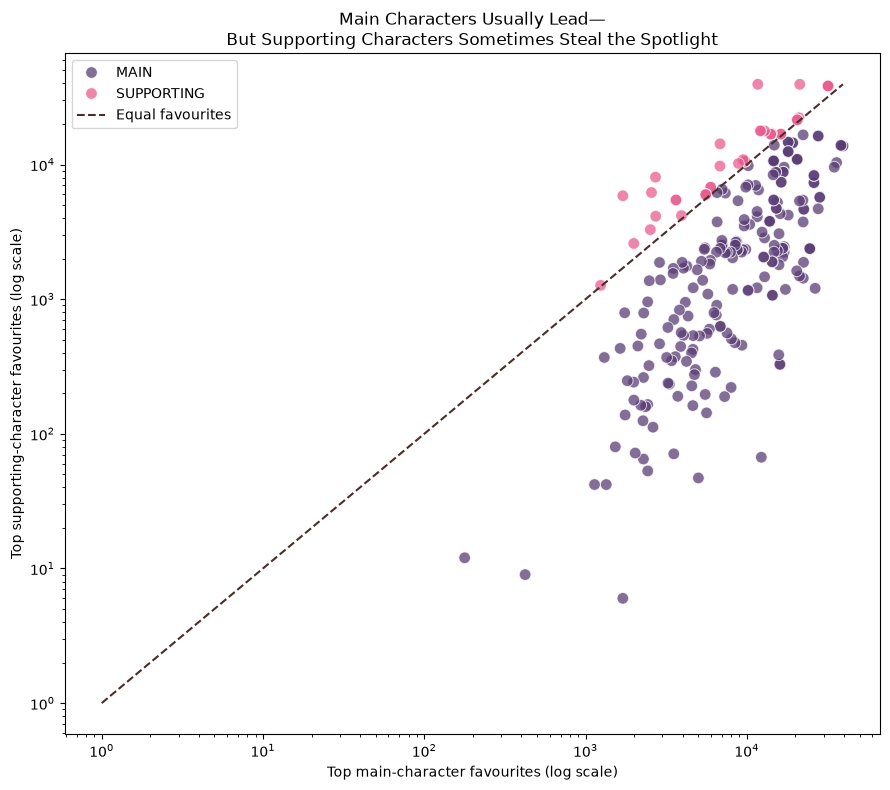

In [36]:
#Main vs Supporting Scatterplot

OUTPUT_CHARTS = (
    PROJECT_ROOT
    / "outputs"
    / "charts"
)

OUTPUT_CHARTS.mkdir(
    parents=True,
    exist_ok=True,
)

plot_matchups = matchups.copy()

# Add one so zero values can appear
# correctly on logarithmic axes.
plot_matchups["main_plot"] = (
    plot_matchups["main_favourites"] + 1
)

plot_matchups["supporting_plot"] = (
    plot_matchups["supporting_favourites"] + 1
)

plt.figure(figsize=(9, 8))

sns.scatterplot(
    data=plot_matchups,
    x="main_plot",
    y="supporting_plot",
    hue="winner_role",
    palette={
        "MAIN": "#5A3D75",
        "SUPPORTING": "#E85D8E",
    },
    alpha=0.75,
    s=70,
)

maximum_value = max(
    plot_matchups["main_plot"].max(),
    plot_matchups["supporting_plot"].max(),
)

plt.plot(
    [1, maximum_value],
    [1, maximum_value],
    linestyle="--",
    color="#4B2E2B",
    label="Equal favourites",
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Main Characters Usually Lead—"
    "\nBut Supporting Characters Sometimes Steal the Spotlight"
)

plt.xlabel(
    "Top main-character favourites "
    "(log scale)"
)

plt.ylabel(
    "Top supporting-character favourites "
    "(log scale)"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_CHARTS
    / "main_vs_supporting_favourites.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Each dot = One Anime Entry

Purple = Main character wins

Pink = Supporting character wins

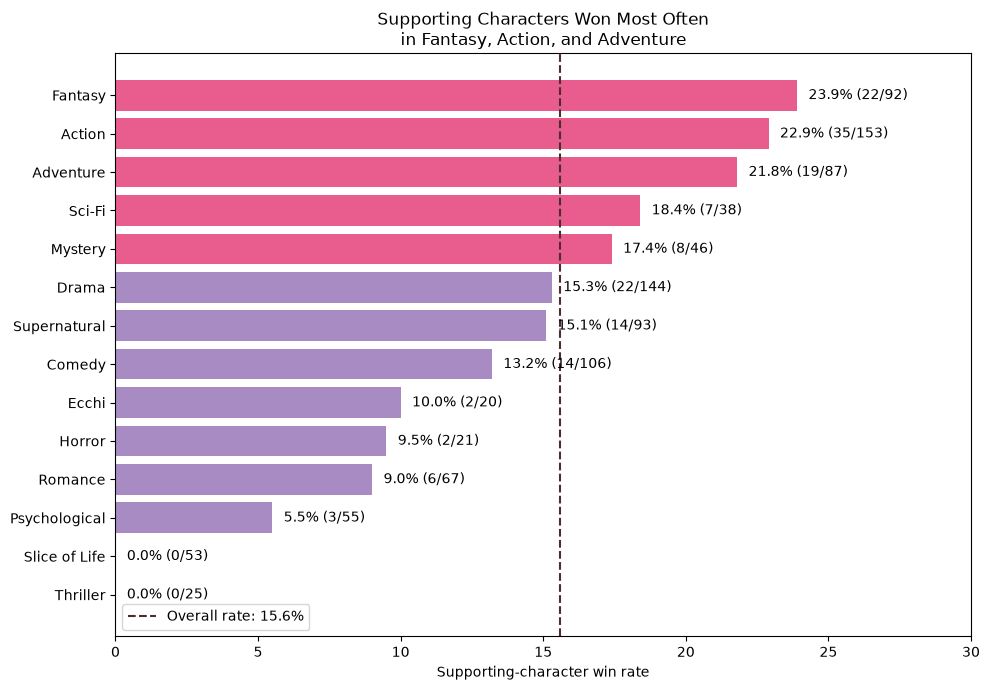

In [37]:
plt.figure(figsize=(10, 7))

genre_colors = [
    "#E85D8E" if rate > 15.6 else "#A88BC2"
    for rate in genre_results["supporting_win_rate"]
]

bars = plt.barh(
    genre_results["genre"],
    genre_results["supporting_win_rate"],
    color=genre_colors,
)

plt.axvline(
    15.6,
    color="#4B2E2B",
    linestyle="--",
    linewidth=1.5,
    label="Overall rate: 15.6%",
)

plt.gca().invert_yaxis()

# Add percentage and counts
for bar, rate, wins, total in zip(
    bars,
    genre_results["supporting_win_rate"],
    genre_results["supporting_wins"],
    genre_results["anime_entries"],
):
    plt.text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}% ({int(wins)}/{int(total)})",
        va="center",
    )

plt.title(
    "Supporting Characters Won Most Often"
    "\nin Fantasy, Action, and Adventure"
)

plt.xlabel("Supporting-character win rate")
plt.ylabel("")

plt.legend()

# Provides room for the longer labels
plt.xlim(0, 30)

plt.tight_layout()

plt.savefig(
    OUTPUT_CHARTS / "supporting_win_rate_by_genre.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Most dots sit below the diagonal, so it is safe to conclude that main characters usually have more favorites. 

Genres overlap, so one anime may appear in multiple categories. These are descriptive patterns, not evidence that genre causes a supporting character to win.

Supporting characters won most often in Fantasy, Action, and Adventure

Biggest Supporting Characters

In [38]:
print(strongest_supporting_upsets.columns.tolist())

display(
    strongest_supporting_upsets.head(10)
)

['anime_id', 'title_display', 'MAIN', 'SUPPORTING', 'supporting_advantage', 'supporting_to_main_ratio']


character_role,anime_id,title_display,MAIN,SUPPORTING,supporting_advantage,supporting_to_main_ratio
215,131573,JUJUTSU KAISEN 0,11693,39436,27743,3.372616
245,172463,JUJUTSU KAISEN Season 3: The Culling Game Part 1,21298,39436,18138,1.851629
164,102883,JoJo's Bizarre Adventure: Golden Wind,6819,14234,7415,2.087403
66,16498,Attack on Titan,31874,38336,6462,1.202736
231,146984,Attack on Titan Final Season THE FINAL CHAPTER...,31874,38336,6462,1.202736
101,20958,Attack on Titan Season 2,31874,38336,6462,1.202736
182,110277,Attack on Titan Final Season,31874,38336,6462,1.202736
216,131681,Attack on Titan Final Season Part 2,31874,38336,6462,1.202736
46,10087,Fate/Zero,12157,17777,5620,1.462285
53,11741,Fate/Zero Season 2,12157,17777,5620,1.462285


In [39]:
print(matchups.columns.tolist())

display(
    matchups.head(3)
)

['anime_id', 'title_display', 'main_character_id', 'top_main_character', 'main_favourites', 'supporting_character_id', 'top_supporting_character', 'supporting_favourites', 'supporting_advantage', 'supporting_to_main_ratio', 'winner_role', 'main_to_supporting_ratio']


,anime_id,title_display,main_character_id,top_main_character,main_favourites,supporting_character_id,top_supporting_character,supporting_favourites,supporting_advantage,supporting_to_main_ratio,winner_role,main_to_supporting_ratio
0,145064,JUJUTSU KAISEN Season 2,127691,Satoru Gojou,39436,133704,Kento Nanami,13738,-25698,0.348362,MAIN,2.870578
1,113415,JUJUTSU KAISEN,127691,Satoru Gojou,39436,133704,Kento Nanami,13738,-25698,0.348362,MAIN,2.870578
2,99147,Attack on Titan Season 3,45627,Levi,38336,71121,Hange Zoe,13871,-24465,0.361827,MAIN,2.763752


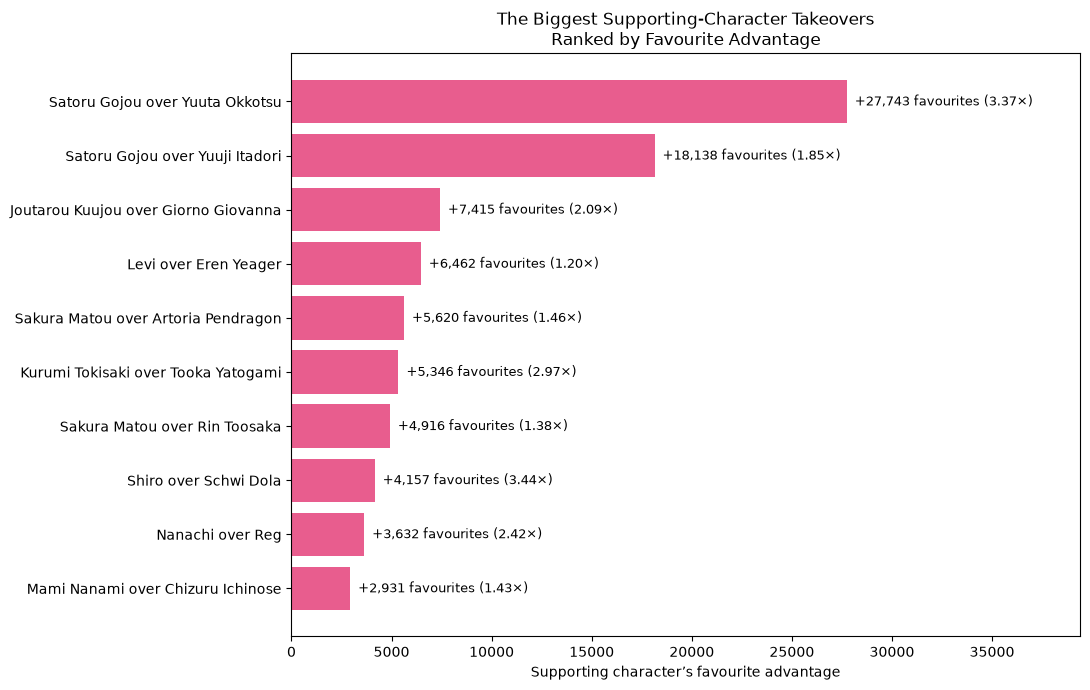

In [40]:
# Keep only anime entries where the supporting character won
# Then remove repeated main-supporting pairings across seasons

unique_supporting_upsets = (
    matchups[
        matchups["winner_role"] == "SUPPORTING"
    ]
    .sort_values(
        "supporting_advantage",
        ascending=False
    )
    .drop_duplicates(
        subset=[
            "main_character_id",
            "supporting_character_id",
        ]
    )
    .copy()
)

# Select the ten biggest takeovers
top_upsets = (
    unique_supporting_upsets
    .nlargest(
        10,
        "supporting_advantage"
    )
    .sort_values(
        "supporting_advantage",
        ascending=True
    )
)

# Create readable matchup labels
top_upsets["matchup_label"] = (
    top_upsets["top_supporting_character"]
    + " over "
    + top_upsets["top_main_character"]
)

# Draw the chart
plt.figure(figsize=(11, 7))

bars = plt.barh(
    top_upsets["matchup_label"],
    top_upsets["supporting_advantage"],
    color="#E85D8E",
)

# Add advantage and ratio labels
for bar, advantage, ratio in zip(
    bars,
    top_upsets["supporting_advantage"],
    top_upsets["supporting_to_main_ratio"],
):
    plt.text(
        bar.get_width() + 400,
        bar.get_y() + bar.get_height() / 2,
        f"+{advantage:,.0f} favourites ({ratio:.2f}×)",
        va="center",
        fontsize=9,
    )

plt.title(
    "The Biggest Supporting-Character Takeovers"
    "\nRanked by Favourite Advantage"
)

plt.xlabel(
    "Supporting character’s favourite advantage"
)

plt.ylabel("")

# Add room for labels
plt.xlim(
    0,
    top_upsets["supporting_advantage"].max() * 1.42
)

plt.tight_layout()

plt.savefig(
    OUTPUT_CHARTS / "biggest_supporting_character_takeovers.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [41]:
display(
    top_upsets[
        [
            "title_display",
            "top_supporting_character",
            "supporting_favourites",
            "top_main_character",
            "main_favourites",
            "supporting_advantage",
            "supporting_to_main_ratio",
        ]
    ].sort_values(
        "supporting_advantage",
        ascending=False
    )
)

,title_display,top_supporting_character,supporting_favourites,top_main_character,main_favourites,supporting_advantage,supporting_to_main_ratio
105,JUJUTSU KAISEN 0,Satoru Gojou,39436,Yuuta Okkotsu,11693,27743,3.372616
31,JUJUTSU KAISEN Season 3: The Culling Game Part 1,Satoru Gojou,39436,Yuuji Itadori,21298,18138,1.851629
152,JoJo's Bizarre Adventure: Golden Wind,Joutarou Kuujou,14234,Giorno Giovanna,6819,7415,2.087403
8,Attack on Titan Final Season Part 2,Levi,38336,Eren Yeager,31874,6462,1.202736
102,Fate/Zero Season 2,Sakura Matou,17777,Artoria Pendragon,12157,5620,1.462285
216,Date A Live,Kurumi Tokisaki,8060,Tooka Yatogami,2714,5346,2.969786
97,Fate/stay night: Unlimited Blade Works,Sakura Matou,17777,Rin Toosaka,12861,4916,1.382241
240,"No Game, No Life Zero",Shiro,5860,Schwi Dola,1703,4157,3.440986
218,Made in Abyss,Nanachi,6194,Reg,2562,3632,2.417642
153,Rent-a-Girlfriend,Mami Nanami,9740,Chizuru Ichinose,6809,2931,1.430460


In [43]:
OUTPUT_TABLES = OUTPUT_CHARTS.parent / "tables"
OUTPUT_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

winner_summary.to_csv(
    OUTPUT_TABLES / "anime_entry_winner_summary.csv",
    index=False
)

unique_matchups.to_csv(
    OUTPUT_TABLES / "unique_character_matchups.csv",
    index=False
)

unique_supporting_winners.to_csv(
    OUTPUT_TABLES / "unique_supporting_winners.csv",
    index=False
)

genre_results.to_csv(
    OUTPUT_TABLES / "supporting_win_rate_by_genre.csv",
    index=False
)

top_upsets.sort_values(
    "supporting_advantage",
    ascending=False
).to_csv(
    OUTPUT_TABLES / "top_supporting_character_takeovers.csv",
    index=False
)

print("Final analysis tables saved")

Final analysis tables saved


## Conclusion

Main characters usually lead their anime's fandom favorites. However, they do not always keep the spotlight.

Across 250 popular anime entries, the most favorited main character won 84.4% of comparisons, while a supporting character won 15.6%. After repeated main-vs-supporting pairings across different seasons were counted only once, the supporting character win rate became 12.8%.

Some supporting-character victories were especially pronounced. Satoru Gojou had 27,743 more favourites than Yuuta Okkotsu in JUJUTSU KAISEN 0, while Shiro had approximately 3.44 times the favourites of Schwi Dola in No Game, No Life Zero.

Supporting-character victories were also more common among Fantasy, Action, and Adventure entries in this sample. However, genres overlap, so a single anime may contribute to multiple genre categories.

Overall, the results suggest that being labelled a main character provides a strong popularity advantage, but narrative role does not guarantee fandom dominance. In approximately one out of every six to eight comparisons, a supporting character still became the audience favourite.


## Limitations
- Character favourites represent the number of AniList users who globally marked a character as a favourite. They are not votes collected specifically for each anime entry.

- The sample contains the 250 most-popular non-adult anime entries available through AniList at the time of extraction and is not representative of every anime.

- Separate seasons, sequels, and films may appear as different anime entries.

- The same character can appear in multiple entries, meaning observations are not completely independent.

- AniList character roles may vary across different entries in the same franchise.

- Genre categories overlap and should not be interpreted as mutually exclusive groups.

- Favourite counts can change over time, so the results represent a dated snapshot.

- The analysis describes associations and does not establish that character role or genre causes popularity.
